# CycleGAN Inference Demo

Dieses Notebook nutzt das neue `src.apply_cyclegan`-Modul, um einen gespeicherten Generator auf Testbilder anzuwenden. Es wählt zufällig 5 Eingabebilder aus, wendet den Generator auf sie an und speichert die Ergebnisse unter `results/cyclegan_inference_demo/<direction>` (der Ordnernamen entspricht dem mapping). Eine Beispielkombination wird anschließend nebeneinander angezeigt.

## Ablauf
1. Konfiguration und Checkpoint laden.
2. Ausgewählte Testbilder aus `data/night2day/night_to_day/testA` bzw. `testB` einlesen.
3. Den passenden Generator (`G` für day→night, `F` für night→day) anwenden.
4. Ergebnisse abspeichern und eine Referenzseite nebeneinander visualisieren.

Wenn du `direction = "night2day"` setzt, verwenden wir automatisch `testB` als Input und `F` als Generator; die Ausgaben landen dann unter `results/cyclegan_inference_demo/night2day`.

In [81]:
from pathlib import Path
import random
import torch
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.transforms import functional as TF

import os

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Current working directory:", os.getcwd())

from src.apply_cyclegan import (
    build_generator,
    gather_image_paths,
    find_checkpoint,
)
from src.utils.common import load_cfg

NUM_SAMPLES = 5  # Anzahl zufällig ausgewählter Bilder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = load_cfg("configs/cyclegan.yaml")



Current working directory: /srv/store/docker-users/thesis/khajuria/day2night


In [82]:
direction = True  # True für "day2night", False für "night2day"
input_dir = Path("data/bdd_split/cyclegan/testA") if direction else Path("data/bdd_split/cyclegan/testB")
#checkpoint = find_checkpoint("experiments/cyclegan_day2night_20251113_232736/epoch_0200.pt", cfg)
checkpoint = find_checkpoint("experiments/cyclegan_day2night_20251113_232736/epoch_0200.pt", cfg)
extensions = cfg["data"].get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(input_dir, extensions)
assert image_paths, "Keine Testbilder gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))
transform = build_inference_transform(cfg)
generator = build_generator(cfg, device)
state = torch.load(checkpoint, map_location="cpu")
key = "G" if direction == "day2night" else "F"
generator.load_state_dict(state[key])

/srv/store/docker-users/thesis/khajuria/day2night/src/models/cyclegan.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=

<All keys matched successfully>

In [83]:
import re
from datetime import datetime

def find_latest_checkpoint(
    checkpoints_dir: Optional[Path | str] = None,
    pattern: str = r"epoch_(\d+)\.pt",
    recursive: bool = True,
) -> Optional[Path]:
    """
    Find the latest checkpoint file in `checkpoints_dir`.

    Behavior:
    - By default uses cfg['logging'].get('out_dir', 'experiments') as directory.
    - If the directory contains experiment subfolders, prefer the most recent
      experiment folder. It tries to parse a timestamp of the form YYYYMMDD_HHMMSS
      from the folder name and picks the newest; if none match, it picks the
      most recently modified folder.
    - Inside the chosen folder, picks the checkpoint with the largest epoch
      number matching `pattern` (default: epoch_####.pt).
    - Falls back to newest .pt by modification time if no epoch pattern matches.
    Returns Path or None if no checkpoint found.
    """
    checkpoints_dir = Path(checkpoints_dir) if checkpoints_dir else Path(cfg.get("logging", {}).get("out_dir", "experiments"))
    if not checkpoints_dir.exists():
        return None

    # If there are experiment subdirectories, try to pick the latest experiment folder
    subdirs = [p for p in checkpoints_dir.iterdir() if p.is_dir()]
    if subdirs:
        # try to parse timestamp like ..._YYYYMMDD_HHMMSS
        ts_re = re.compile(r"(\d{8}_\d{6})")
        dated = []
        for d in subdirs:
            m = ts_re.search(d.name)
            if m:
                try:
                    dt = datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
                    dated.append((dt, d))
                except ValueError:
                    continue
        if dated:
            search_dir = max(dated, key=lambda x: x[0])[1]
        else:
            # fallback to most recently modified subdir
            search_dir = max(subdirs, key=lambda p: p.stat().st_mtime)
    else:
        search_dir = checkpoints_dir

    files = list(search_dir.rglob("*.pt") if recursive else search_dir.glob("*.pt"))
    if not files:
        return None

    epoched = []
    for p in files:
        m = re.search(pattern, p.name)
        if m:
            try:
                epoched.append((int(m.group(1)), p))
            except Exception:
                continue

    if epoched:
        # return file with max epoch
        return max(epoched, key=lambda x: x[0])[1]

    # fallback: return most recently modified .pt
    return max(files, key=lambda p: p.stat().st_mtime)

# quick usage
checkpoint = find_latest_checkpoint()
print("Latest checkpoint:", checkpoint)

output_dir = Path("results/cyclegan_inference_demo") / checkpoint.parent.name / ("day2night" if direction else "night2day")
output_dir.mkdir(parents=True, exist_ok=True)


Latest checkpoint: experiments/cyclegan_day2night_20251124_002331/epoch_0200.pt


In [84]:
direction = True  # True für "day2night", False für "night2day"
input_dir = Path("data/bdd_split/cyclegan/testA") if direction else Path("data/bdd_split/cyclegan/testB")
#checkpoint = find_checkpoint("experiments/cyclegan_day2night_20251113_232736/epoch_0200.pt", cfg)
#checkpoint = find_checkpoint("experiments/cyclegan_day2night_20251113_232736/epoch_0200.pt", cfg)
extensions = cfg["data"].get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(input_dir, extensions)
assert image_paths, "Keine Testbilder gefunden."
sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))

CROP_SIZE = 512  # CenterCrop, falls das Bild größer ist
TARGET_SIZE = 256  # anschließend auf Modell-Eingangsgröße bringen

# Generator + Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Hinweis: apply_cyclegan.py prüft auf feste Größe; hier erzwingen wir eine Resize nach dem Crop.
generator = build_generator(cfg, device)
state = torch.load(checkpoint, map_location="cpu")
key = "G" if direction == "day2night" else "F"
generator.load_state_dict(state[key])
output_dir = Path("results/cyclegan_inference_demo") / checkpoint.parent.name / ("day2night" if direction else "night2day")
output_dir.mkdir(parents=True, exist_ok=True)

def preprocess(img: Image.Image):
    # center-crop auf min(CROP_SIZE, kürzere Seite), danach Resize auf TARGET_SIZE
    crop_dim = min(CROP_SIZE, img.width, img.height)
    cropped = TF.center_crop(img, crop_dim)
    resized = cropped.resize((TARGET_SIZE, TARGET_SIZE), Image.BICUBIC)
    return resized, cropped.size

results_info = []
generator.eval()
to_pil = transforms.ToPILImage()
with torch.inference_mode():
    for image_path in sample_paths:
        img = Image.open(image_path).convert("RGB")
        orig_size = img.size
        processed_img, cropped_size = preprocess(img)
        input_tensor = transform(processed_img).unsqueeze(0).to(device)
        output_tensor = generator(input_tensor).squeeze(0).cpu()
        output_tensor = output_tensor.mul(0.5).add(0.5).clamp(0.0, 1.0)
        result_img = to_pil(output_tensor)
        destination = output_dir / image_path.relative_to(input_dir)
        destination.parent.mkdir(parents=True, exist_ok=True)
        result_img.save(destination)
        results_info.append((image_path, destination, orig_size, cropped_size, result_img.size))

print(f"Speicherort der generierten Bilder: {output_dir}")
print(f"Pipeline: CenterCrop auf {CROP_SIZE} -> Resize auf {TARGET_SIZE}x{TARGET_SIZE} -> Generator -> Ausgabe gespeichert.")


/tmp/ipykernel_958563/3687109302.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint, map_location="cpu")


Speicherort der generierten Bilder: results/cyclegan_inference_demo/cyclegan_day2night_20251124_002331/day2night
Pipeline: CenterCrop auf 512 -> Resize auf 256x256 -> Generator -> Ausgabe gespeichert.


Anzeigen von Beispielen aus: results/cyclegan_inference_demo/cyclegan_day2night_20251124_002331/day2night
Eingabeverzeichnis: data/bdd_split/cyclegan/testA


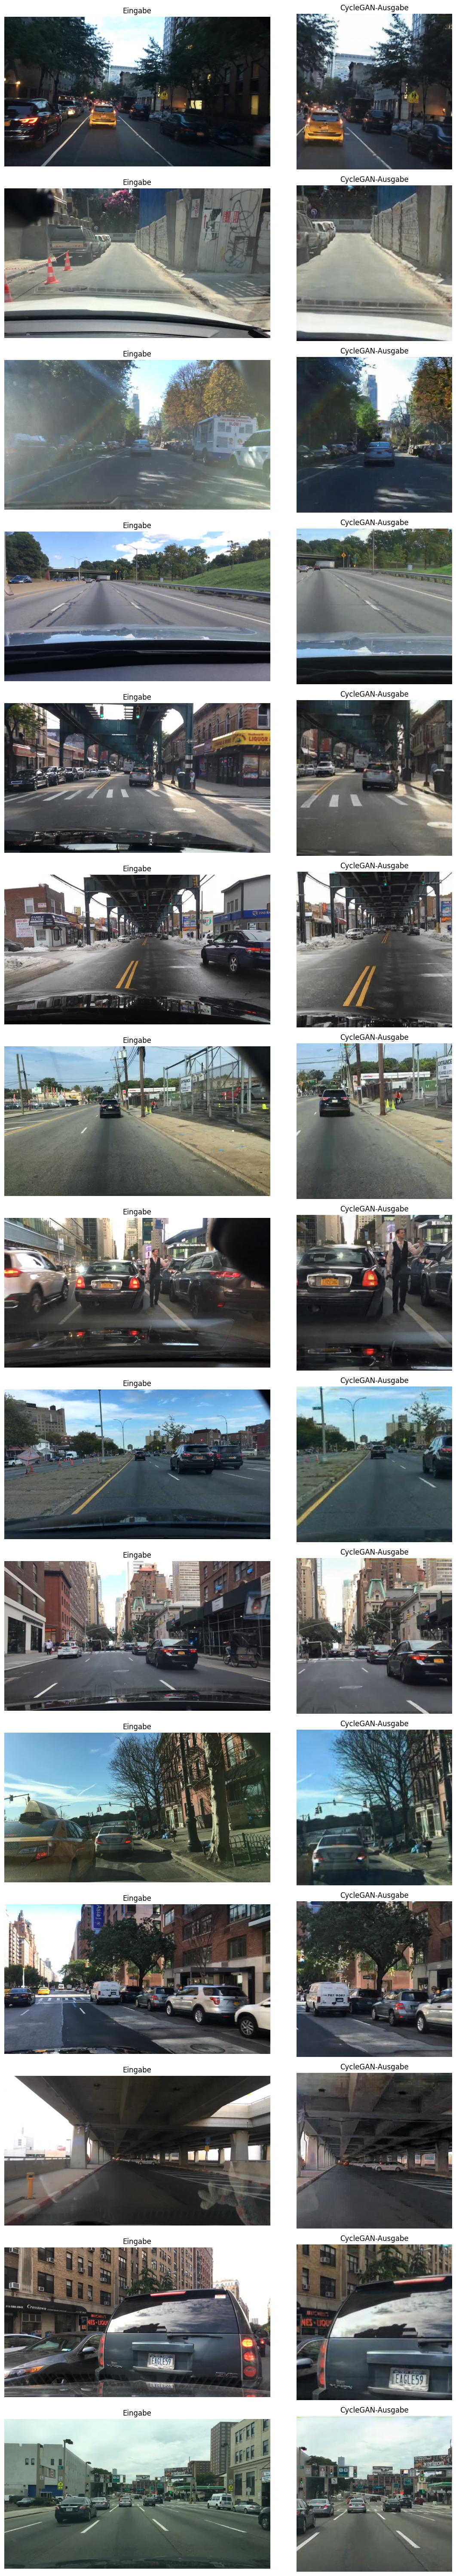

In [85]:
#output_dir = Path("results/cyclegan_inference_demo") / ("day2night" if direction else "night2day")
#input_dir = Path("data/night2day/night_to_day") / ("testA" if direction else "testB" )  # Ursprüngliches Eingabeverzeichnis
print(f"Anzeigen von Beispielen aus: {output_dir}")
print(f"Eingabeverzeichnis: {input_dir}")
def show_samples(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    # all images in output_dir
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    output_files = sorted(
        p for p in output_dir.rglob("*") if p.suffix.lower() in exts
    )

    rows = max(1, len(output_files))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, 2)

    for row_idx, output_path in enumerate(output_files):
        # try to find matching input image by filename
        matches = list(input_dir.rglob(output_path.name))
        if not matches:
            print(f"No input found for {output_path.name}")
            continue
        input_path = matches[0]

        for col_idx, (path, title) in enumerate((
            (input_path, "Eingabe"),
            (output_path, "CycleGAN-Ausgabe"),
        )):
            ax = axes[row_idx, col_idx]
            ax.imshow(Image.open(path))
            ax.set_title(title)
            ax.axis("off")

    plt.tight_layout()


show_samples(input_dir, output_dir)


In [86]:
print('Größen: Original -> Crop -> gespeicherte Ausgabe')
for input_path, output_path, orig_size, crop_size, out_size in results_info:
    print(f"{input_path.name}: original={orig_size} crop={crop_size} out_saved={out_size}")



Größen: Original -> Crop -> gespeicherte Ausgabe
b97e697f-1c37913f.jpg: original=(1280, 720) crop=(512, 512) out_saved=(256, 256)
bf5e662c-dba716fd.jpg: original=(1280, 720) crop=(512, 512) out_saved=(256, 256)
bda04f67-927d28d6.jpg: original=(1280, 720) crop=(512, 512) out_saved=(256, 256)
b4082905-e694720e.jpg: original=(1280, 720) crop=(512, 512) out_saved=(256, 256)
c91a84db-f40ee6d0.jpg: original=(1280, 720) crop=(512, 512) out_saved=(256, 256)


### Hinweise
- Die generierten Bilder stehen unter `results/cyclegan_inference_demo/day2night` oder `.../night2day`.
- Der verwendete Checkpoint ist `experiments/cyclegan_day2night_20251110_163433/epoch_0140.pt`.
- Du kannst `direction` ändern, um das night→day-Mapping zu nutzen; das Notebook wechselt dann automatisch zu `testB` und zum Generator `F`.
- Das `apply_generator`-Modul sichert die Eingaben/Ausgaben recht ähnlich zur CLI, sodass du dich auf den Ordner `results/cyclegan_inference_demo/<direction>` verlassen kannst.

In [87]:
from src.models.cyclegan import PatchDiscriminator

mapping = "day2night" if direction else "night2day"
target_domain = "night" if direction else "day"

disc_cfg = cfg["model"]["discriminator"]
D_day = PatchDiscriminator(
    in_channels=disc_cfg.get("in_channels", 3),
    base_channels=disc_cfg.get("base_channels", 64),
    n_layers=disc_cfg.get("n_layers", 3),
    max_channels=disc_cfg.get("max_channels", 512),
    use_spectral_norm=disc_cfg.get("use_spectral_norm", False),
).to(device)
D_night = PatchDiscriminator(
    in_channels=disc_cfg.get("in_channels", 3),
    base_channels=disc_cfg.get("base_channels", 64),
    n_layers=disc_cfg.get("n_layers", 3),
    max_channels=disc_cfg.get("max_channels", 512),
    use_spectral_norm=disc_cfg.get("use_spectral_norm", False),
).to(device)
D_day.load_state_dict(state["D_day"])
D_night.load_state_dict(state["D_night"])
D_day.eval(); D_night.eval(); generator.eval()

def score_image(image_path: Path):
    img = Image.open(image_path).convert("RGB")
    cropped, _ = preprocess(img)
    inp = transform(cropped).unsqueeze(0).to(device)
    day_score = torch.sigmoid(D_day(inp)).mean().item()
    night_score = torch.sigmoid(D_night(inp)).mean().item()
    identity_l1 = torch.mean(torch.abs(generator(inp) - inp)).item()
    predicted = "day" if day_score >= night_score else "night"
    print(f"{image_path.name}: D_day={day_score:.4f}  D_night={night_score:.4f}  id_L1={identity_l1:.4f} -> {predicted} (target={target_domain})")
    return day_score, night_score, identity_l1

print("Diskriminator-Einschätzung (Input-Bild, vor der Umwandlung):")
for path in sample_paths:
    score_image(path)


Diskriminator-Einschätzung (Input-Bild, vor der Umwandlung):
b97e697f-1c37913f.jpg: D_day=0.6120  D_night=0.6644  id_L1=0.0703 -> night (target=night)
bf5e662c-dba716fd.jpg: D_day=0.6334  D_night=0.6599  id_L1=0.0563 -> night (target=night)
bda04f67-927d28d6.jpg: D_day=0.6807  D_night=0.7032  id_L1=0.0273 -> night (target=night)
b4082905-e694720e.jpg: D_day=0.6637  D_night=0.7254  id_L1=0.0713 -> night (target=night)
c91a84db-f40ee6d0.jpg: D_day=0.5899  D_night=0.6622  id_L1=0.0525 -> night (target=night)
